### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END

## Reducers
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages:Annotated[list,add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

# os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [5]:
from langchain_openai import ChatOpenAI
llm=ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_4b1fc28435', 'id': 'chatcmpl-DQaT3oUmdIfxrj7GiFL0Db7S8O7ja', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d53e6-11db-7d42-8bc6-e5bdd44a964d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [4]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="qwen/qwen3-32b")
llm_groq.invoke("Hey I am Arun Mathe and i like to play cricket")

AIMessage(content="<think>\nOkay, the user is Arun Mathe and he likes to play cricket. I need to respond in a friendly way. Maybe ask him about his favorite team or any specific role he plays in cricket. I should keep it engaging so he feels comfortable to share more. Also, maybe mention some tips or fun facts about cricket to keep the conversation flowing. Let me make sure the tone is positive and encouraging.\n</think>\n\nHi Arun! Nice to meet you! 🏏 I love that you enjoy cricket—it's such an exciting game! Do you have a favorite team you follow, or do you play a specific role like batting, bowling, or fielding? I'd love to hear more about what you enjoy most about the sport! 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 154, 'prompt_tokens': 21, 'total_tokens': 175, 'completion_time': 0.349974011, 'completion_tokens_details': None, 'prompt_time': 0.000663521, 'prompt_tokens_details': None, 'queue_time': 0.046044408, 'total_time': 0.350637532}, 'mo

### We Will start With Creating Nodes

In [5]:
def superbot(state:State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

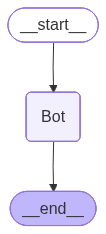

In [6]:
graph=StateGraph(State)

## node
graph.add_node("Bot",superbot)
## Edges

graph.add_edge(START,"Bot")
graph.add_edge("Bot",END)


graph_builder=graph.compile()


## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [7]:
## Invocation

graph_builder.invoke({'messages':"Hi"})

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='0a528da6-3ad3-46d2-9d87-ffa0ce2b8c38'),
  AIMessage(content='<think>\nOkay, the user sent "Hi". That\'s pretty open-ended. I need to figure out the best way to respond. Since they didn\'t ask a specific question, maybe I should greet them back and offer assistance. Let me check the guidelines. I should be friendly and encourage them to ask questions or share what\'s on their mind. Maybe something like, "Hello! How can I assist you today?" That should work. It\'s welcoming and opens the door for them to explain what they need help with. I don\'t see any other context here, so keeping it general makes sense. Alright, let\'s go with that.\n</think>\n\nHello! How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 141, 'prompt_tokens': 9, 'total_tokens': 150, 'completion_time': 0.30733291, 'completion_tokens_details': None, 'prompt_time': 0.000258926,

In [11]:
graph_builder.invoke({'messages':"i am reading technical books and suggest me langgraph books?"})

{'messages': [HumanMessage(content='i am reading technical books and suggest me langgraph books?', additional_kwargs={}, response_metadata={}, id='73c4366a-f47c-4b97-af35-172d1f45d2ab'),
  AIMessage(content='<think>\nOkay, the user is reading technical books and wants suggestions on LangGraph books. First, I need to figure out what LangGraph is. Wait, maybe they mean LangChain? Because LangGraph isn\'t a widely known framework. LangChain is a popular framework for building applications with large language models. Maybe there\'s a typo.\n\nAssuming they meant LangChain, I should check if there are any official books or resources. Let me think. I recall that there\'s a book called "LangChain: From Zero to Production" by Harrison Chase, the creator of LangChain. That\'s probably a good starting point. Also, the official LangChain documentation is comprehensive and might be considered a resource, though not a book.\n\nAre there other books or resources? Maybe some tutorials or GitHub repos

In [12]:
graph_builder.invoke({'messages':"provide me a simple langgraph code example"})

{'messages': [HumanMessage(content='provide me a simple langgraph code example', additional_kwargs={}, response_metadata={}, id='0331ed01-7c0a-4585-9f5a-82ff485e6497'),
  AIMessage(content='<think>\nOkay, the user wants a simple LangGraph code example. Let me start by recalling what LangGraph is. Oh right, it\'s a library for building stateful, graph-based agents with LangChain. So I need to create a basic example that demonstrates its core features.\n\nFirst, I should think about the components needed. LangGraph uses nodes, edges, and a graph structure. Maybe a simple example with a couple of nodes that process some input and pass it along. Let me consider a scenario where one node processes an input, then another node uses the result. Like a chain: input -> node A (modifies text) -> node B (modifies again), then output.\n\nWait, but LangGraph might have a specific way of defining the graph. I remember that you define nodes as functions and connect them with edges. Also, you need to u